In [1]:
#Load packages
import pandas as pd
import numpy as np

# I. Comparing Event Run Values

In [9]:
# Read in MLBAM Data for 2014-2017

MLBAM14 = pd.read_csv("../Data/MLBAM14.csv")
MLBAM15 = pd.read_csv("../Data/MLBAM15.csv")
MLBAM16 = pd.read_csv("../Data/MLBAM16.csv")
MLBAM17 = pd.read_csv("../Data/MLBAM17.csv")

In [10]:
#Your Code Here
def Run_Expectancy(path):
    
    RE = path
    RE.drop(['Unnamed: 0'], axis=1, inplace=True)
    RE = RE[['home_team','away_team','half','gameId','batterName','batterId','event', 'start1B', 'start2B', 'start3B',\
             'end1B', 'end2B', 'end3B', 'startOuts','endOuts','runsFuture','runsOnPlay','outsInInning','venueId','batterPos']]
    RE['Start1'] = np.where(pd.isnull(RE['start1B']),0,1)
    RE['Start2'] = np.where(pd.isnull(RE['start2B']),0,1)
    RE['Start3'] = np.where(pd.isnull(RE['start3B']),0,1)
    RE['Start_State'] = (RE['Start1'].astype(str) + RE['Start2'].astype(str) + RE['Start3'].astype(str)+\
                          " " + RE['startOuts'].astype(str))
    RE['End1'] = np.where(pd.isnull(RE['end1B']),0,1)
    RE['End2'] = np.where(pd.isnull(RE['end2B']),0,1)
    RE['End3'] = np.where(pd.isnull(RE['end3B']),0,1)
    RE['End_State'] = (RE['End1'].astype(str) + RE['End2'].astype(str) + RE['End3'].astype(str) + \
                        " " + RE['endOuts'].astype(str))
    RE = RE[((RE.Start_State != RE.End_State) | (RE.runsOnPlay > 0)) & (RE.outsInInning == 3)]
    Start_RunExp = RE.groupby(['Start_State'])['runsFuture'].mean().reset_index().rename(columns={'runsFuture':'Start_RE'})
    RE = pd.merge(RE, Start_RunExp, on=['Start_State'], how='left')
    Base_State_3 = [pd.Series(['000 3', 0], index=Start_RunExp.columns),
                pd.Series(['001 3', 0], index=Start_RunExp.columns),
                pd.Series(['010 3', 0], index=Start_RunExp.columns),
                pd.Series(['011 3', 0], index=Start_RunExp.columns),
                pd.Series(['100 3', 0], index=Start_RunExp.columns),
                pd.Series(['101 3', 0], index=Start_RunExp.columns),
                pd.Series(['110 3', 0], index=Start_RunExp.columns),
                pd.Series(['111 3', 0], index=Start_RunExp.columns)]
    Start_RunExp = Start_RunExp.append(Base_State_3, ignore_index=True)
    End_RunExp  = Start_RunExp.rename(columns={'Start_State':'End_State', 'Start_RE':'End_RE'})
    RE = pd.merge(RE, End_RunExp, on=['End_State'], how='left')
    RE['Run_Value'] = RE['runsOnPlay'] + RE['End_RE'] - RE['Start_RE']
    
    return RE;

In [11]:
RE_17 = Run_Expectancy(MLBAM17)
RE_16 = Run_Expectancy(MLBAM16)
RE_15 = Run_Expectancy(MLBAM15)
RE_14 = Run_Expectancy(MLBAM14)

In [13]:
Event_Value17= RE_17.groupby(['event'])['Run_Value'].mean().reset_index().rename(columns = {"Run_Value": 'RV17'})
Event_Value16= RE_16.groupby(['event'])['Run_Value'].mean().reset_index().rename(columns = {"Run_Value": 'RV16'})
Event_Value15= RE_15.groupby(['event'])['Run_Value'].mean().reset_index().rename(columns = {"Run_Value": 'RV15'})
Event_Value14= RE_14.groupby(['event'])['Run_Value'].mean().reset_index().rename(columns = {"Run_Value": 'RV14'})

In [22]:
RVseasons= pd.merge(Event_Value16,Event_Value17, on = ['event'])
RVseasons = pd.merge(RVseasons,Event_Value15, on = ['event'])
RVseasons = pd.merge(RVseasons,Event_Value14, on = ['event'])
RVseasons

,event,RV16,RV17,RV15,RV14
0,Batter Interference,-0.284649,-0.430019,-0.363838,-0.319625
1,Bunt Groundout,-0.218826,-0.209411,-0.200346,-0.194784
2,Bunt Lineout,-0.352295,-0.328292,-0.421575,-0.303810
3,Bunt Pop Out,-0.342802,-0.373225,-0.354384,-0.316440
4,Catcher Interference,0.301623,0.399070,0.318276,0.380337
5,Double,0.743467,0.779338,0.752039,0.737518
6,Double Play,-0.864981,-0.897164,-0.854665,-0.828774
7,Fan interference,0.533316,0.590743,0.577453,0.633560
8,Field Error,0.469989,0.493206,0.485460,0.462976
9,Fielders Choice,0.701447,0.764112,0.719351,0.698076


In [29]:
RVseasons.corr()

,RV16,RV17,RV15,RV14
RV16,1.000000,0.994964,0.997570,0.997951
RV17,0.994964,1.000000,0.996412,0.997153
RV15,0.997570,0.996412,1.000000,0.998819
RV14,0.997951,0.997153,0.998819,1.000000


In [30]:
RVseasons['mean'] = (RVseasons['RV14']+RVseasons['RV15']+RVseasons['RV16']+RVseasons['RV17'])/4
RVseasons['sum_square'] = (RVseasons['RV14']-RVseasons['mean'])**2 + (RVseasons['RV15']-RVseasons['mean'])**2 + (RVseasons['RV16']-RVseasons['mean'])**2 + (RVseasons['RV17']-RVseasons['mean'])**2
RVseasons

,event,RV16,RV17,RV15,RV14,mean,sum_square
0,Batter Interference,-0.284649,-0.430019,-0.363838,-0.319625,-0.349533,0.011787
1,Bunt Groundout,-0.218826,-0.209411,-0.200346,-0.194784,-0.205842,0.000334
2,Bunt Lineout,-0.352295,-0.328292,-0.421575,-0.303810,-0.351493,0.007724
3,Bunt Pop Out,-0.342802,-0.373225,-0.354384,-0.316440,-0.346713,0.001694
4,Catcher Interference,0.301623,0.399070,0.318276,0.380337,0.349826,0.006675
5,Double,0.743467,0.779338,0.752039,0.737518,0.753091,0.001025
6,Double Play,-0.864981,-0.897164,-0.854665,-0.828774,-0.861396,0.002402
7,Fan interference,0.533316,0.590743,0.577453,0.633560,0.583768,0.005113
8,Field Error,0.469989,0.493206,0.485460,0.462976,0.477908,0.000577
9,Fielders Choice,0.701447,0.764112,0.719351,0.698076,0.720747,0.002769


# II. Comparing Player Run Values

In [33]:
#Your Code Here
Player_Value17 = RE_17.groupby(['batterId','batterName'])['Run_Value'].sum().reset_index().rename(columns = {"Run_Value": 'RV17'})
Player_Value16 = RE_16.groupby(['batterId','batterName'])['Run_Value'].sum().reset_index().rename(columns = {"Run_Value": 'RV16'})
Player_Value15 = RE_15.groupby(['batterId','batterName'])['Run_Value'].sum().reset_index().rename(columns = {"Run_Value": 'RV15'})
Player_Value14 = RE_14.groupby(['batterId','batterName'])['Run_Value'].sum().reset_index().rename(columns = {"Run_Value": 'RV14'})

In [36]:
Players = pd.merge(Player_Value16,Player_Value17, on = ['batterId','batterName'])
Players = pd.merge(Players,Player_Value15, on = ['batterId','batterName'])
Players = pd.merge(Players,Player_Value14, on = ['batterId','batterName'])
Players.drop(columns='batterId',inplace=True)
Players

,batterName,RV16,RV17,RV15,RV14
0,Colon,-15.380841,-6.053060,-8.838568,-0.709186
1,Beltre,29.745115,27.205050,11.918638,29.004125
2,Beltran,21.279393,-16.883042,2.355753,-6.208773
3,Werth,6.368448,-7.246145,-3.377653,37.882267
4,Sabathia,-0.944580,-0.292495,-0.472414,-1.118087
5,Dickey,-0.291686,-11.955467,-0.858198,-2.106986
6,"Suzuki, I",-2.577561,1.083044,-24.883224,-3.235189
7,"Martinez, V",7.335464,-16.021087,-10.998931,54.087837
8,Utley,6.689794,-1.799883,-12.196781,15.964367
9,Pujols,15.581010,-13.892055,9.840138,17.629365


In [37]:
Players.corr()

,RV16,RV17,RV15,RV14
RV16,1.000000,0.457391,0.546136,0.426629
RV17,0.457391,1.000000,0.510132,0.322764
RV15,0.546136,0.510132,1.000000,0.466299
RV14,0.426629,0.322764,0.466299,1.000000


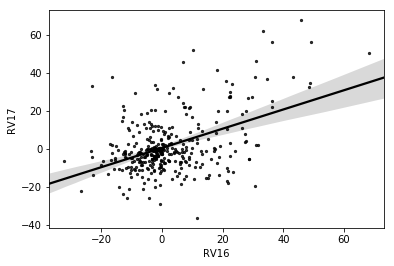

In [40]:
import seaborn as sns
sns.regplot(x="RV16", y="RV17", color= 'black', fit_reg= True ,scatter_kws={'s':5},data= Players)

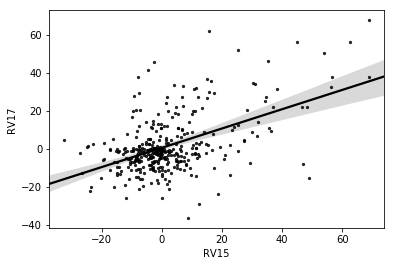

In [41]:
sns.regplot(x="RV15", y="RV17", color= 'black', fit_reg= True ,scatter_kws={'s':5},data= Players)

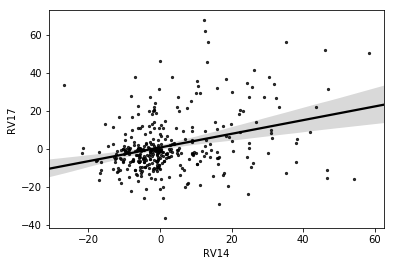

In [42]:
sns.regplot(x="RV14", y="RV17", color= 'black', fit_reg= True ,scatter_kws={'s':5},data= Players)

In [48]:
import statsmodels.formula.api as smf
model = smf.ols(formula='RV17 ~ RV16 + RV15 + RV14', data=Players).fit()
display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   RV17   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     54.61
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           3.20e-29
Time:                        11:19:52   Log-Likelihood:                -1458.4
No. Observations:                 372   AIC:                             2925.
Df Residuals:                     368   BIC:                             2941.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0472      0.650      0.073      0.942      -1.231       1.326
RV16           0.2673      0.059      4.532      0.000       0.151       0.383
RV15           0.3509      0.054      6.480      0.000       0.244       0.457
RV14           0.0620      0.056      1.101      0.272      -0.049       0.173
==============================================================================
Omnibus:                       39.399   Durbin-Watson:                   1.924
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               89.833
Skew:                           0.548   Prob(JB):                     3.11e-20
Kurtosis:                       5.144   Cond. No.                         20.1
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# III. Comparing Team Run Values

In [49]:
#Your Code Here
RE_17['team']= np.where(RE_17['half']=='top',RE_17['away_team'],RE_17['home_team'])
RE_16['team']= np.where(RE_16['half']=='top',RE_16['away_team'],RE_16['home_team'])
RE_15['team']= np.where(RE_15['half']=='top',RE_15['away_team'],RE_15['home_team'])
RE_14['team']= np.where(RE_14['half']=='top',RE_14['away_team'],RE_14['home_team'])

In [50]:
REteam_17= RE_17.groupby(['team'])['Run_Value'].sum().reset_index().rename(columns= {"Run_Value": 'RV17'})
REteam_16= RE_16.groupby(['team'])['Run_Value'].sum().reset_index().rename(columns= {"Run_Value": 'RV16'})
REteam_15= RE_15.groupby(['team'])['Run_Value'].sum().reset_index().rename(columns= {"Run_Value": 'RV15'})
REteam_14= RE_14.groupby(['team'])['Run_Value'].sum().reset_index().rename(columns= {"Run_Value": 'RV14'})
REteam14151617 = pd.merge(REteam_14,REteam_15, on=['team'])
REteam14151617 = pd.merge(REteam14151617,REteam_16, on=['team'])
REteam14151617 = pd.merge(REteam14151617,REteam_17, on=['team'])
REteam14151617

,team,RV14,RV15,RV16,RV17
0,ana,104.641532,-25.056067,-3.184209,-47.579782
1,ari,-48.253012,31.924551,15.870968,62.616716
2,atl,-81.885752,-108.464134,-84.633901,-28.259905
3,bal,46.586965,29.882644,29.297940,-23.678031
4,bos,-37.383914,65.372953,160.812546,9.445347
5,cha,-1.307578,-79.136738,-41.643638,-47.416033
6,chn,-54.987532,-3.627047,85.327151,71.002092
7,cin,-57.227567,-61.401274,-17.643638,5.420218
8,cle,-3.725729,-4.178644,48.815791,73.780465
9,col,92.456063,47.127799,122.825528,78.616716


In [51]:
REteam14151617.corr()

,RV14,RV15,RV16,RV17
RV14,1.000000,0.363681,0.261814,0.065225
RV15,0.363681,1.000000,0.437610,0.193061
RV16,0.261814,0.437610,1.000000,0.351708
RV17,0.065225,0.193061,0.351708,1.000000


In [52]:
model = smf.ols(formula='RV17 ~ RV16 + RV15 + RV14', data=REteam14151617).fit()
display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   RV17   R-squared:                       0.127
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     1.265
Date:                Thu, 23 Apr 2026   Prob (F-statistic):              0.307
Time:                        11:24:09   Log-Likelihood:                -166.93
No. Observations:                  30   AIC:                             341.9
Df Residuals:                      26   BIC:                             347.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.4437     12.406     -0.036      0.972     -25.944      25.056
RV16           0.3788      0.231      1.638      0.113      -0.097       0.854
RV15           0.0706      0.240      0.294      0.771      -0.424       0.565
RV14          -0.0553      0.241     -0.230      0.820      -0.550       0.440
==============================================================================
Omnibus:                        0.584   Durbin-Watson:                   1.712
Prob(Omnibus):                  0.747   Jarque-Bera (JB):                0.061
Skew:                           0.065   Prob(JB):                        0.970
Kurtosis:                       3.179   Cond. No.                         77.2
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""